In [ ]:
from google.colab import files

uploaded = files.upload()

Saving flipkart_iphone16_supply_chain.csv to flipkart_iphone16_supply_chain.csv


In [ ]:
import pandas as pd

df = pd.read_csv("flipkart_iphone16_supply_chain.csv")

df.head()

,Date,Product,Daily_Demand,Opening_Inventory,Shipment_Received,Lead_Time,Reorder_Flag,Order_Quantity,Closing_Inventory,Stockout,Holding_Cost,Stockout_Cost
0,2024-01-01,iPhone 16,15,500,0,NaN,0,0,485,0,2425,0
1,2024-01-02,iPhone 16,12,485,0,NaN,0,0,473,0,2365,0
2,2024-01-03,iPhone 16,18,473,0,NaN,0,0,455,0,2275,0
3,2024-01-04,iPhone 16,13,455,0,NaN,0,0,442,0,2210,0
4,2024-01-05,iPhone 16,20,442,0,NaN,0,0,422,0,2110,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               90 non-null     object 
 1   Product            90 non-null     object 
 2   Daily_Demand       90 non-null     int64  
 3   Opening_Inventory  90 non-null     int64  
 4   Shipment_Received  90 non-null     int64  
 5   Lead_Time          5 non-null      float64
 6   Reorder_Flag       90 non-null     int64  
 7   Order_Quantity     90 non-null     int64  
 8   Closing_Inventory  90 non-null     int64  
 9   Stockout           90 non-null     int64  
 10  Holding_Cost       90 non-null     int64  
 11  Stockout_Cost      90 non-null     int64  
dtypes: float64(1), int64(9), object(2)
memory usage: 8.6+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Product,0
Daily_Demand,0
Opening_Inventory,0
Shipment_Received,0
Lead_Time,85
Reorder_Flag,0
Order_Quantity,0
Closing_Inventory,0
Stockout,0


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Product,Daily_Demand,Opening_Inventory,Shipment_Received,Lead_Time,Reorder_Flag,Order_Quantity,Closing_Inventory,Stockout,Holding_Cost,Stockout_Cost
0,2024-01-01,iPhone 16,15,500,0,NaN,0,0,485,0,2425,0
1,2024-01-02,iPhone 16,12,485,0,NaN,0,0,473,0,2365,0
2,2024-01-03,iPhone 16,18,473,0,NaN,0,0,455,0,2275,0
3,2024-01-04,iPhone 16,13,455,0,NaN,0,0,442,0,2210,0
4,2024-01-05,iPhone 16,20,442,0,NaN,0,0,422,0,2110,0


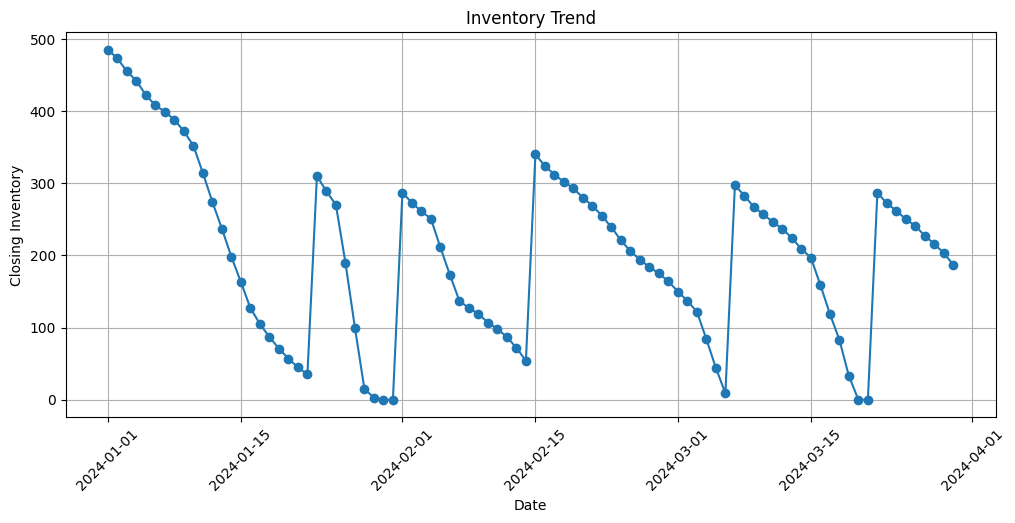

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Closing_Inventory"], marker="o")
plt.title("Inventory Trend")
plt.xlabel("Date")
plt.ylabel("Closing Inventory")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

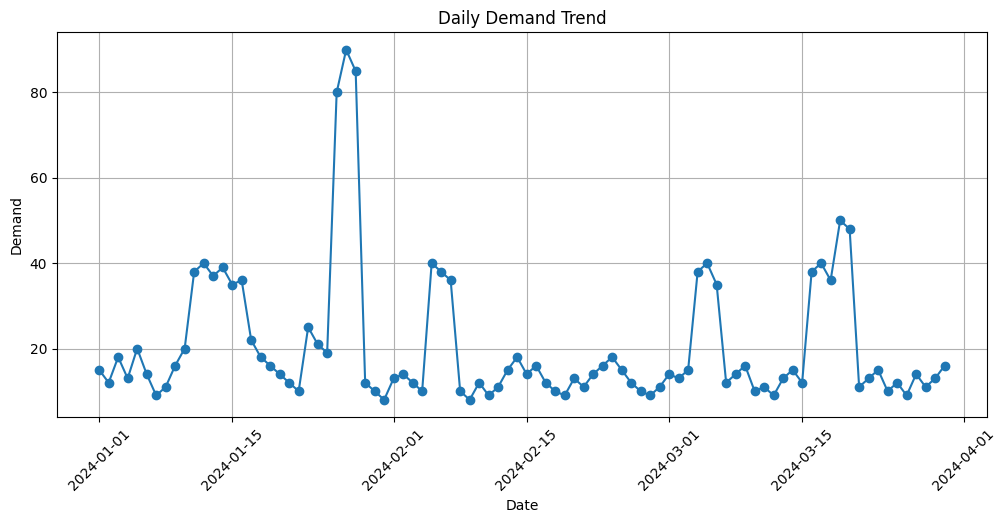

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Daily_Demand"], marker="o")
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Total Stockout Days: 41


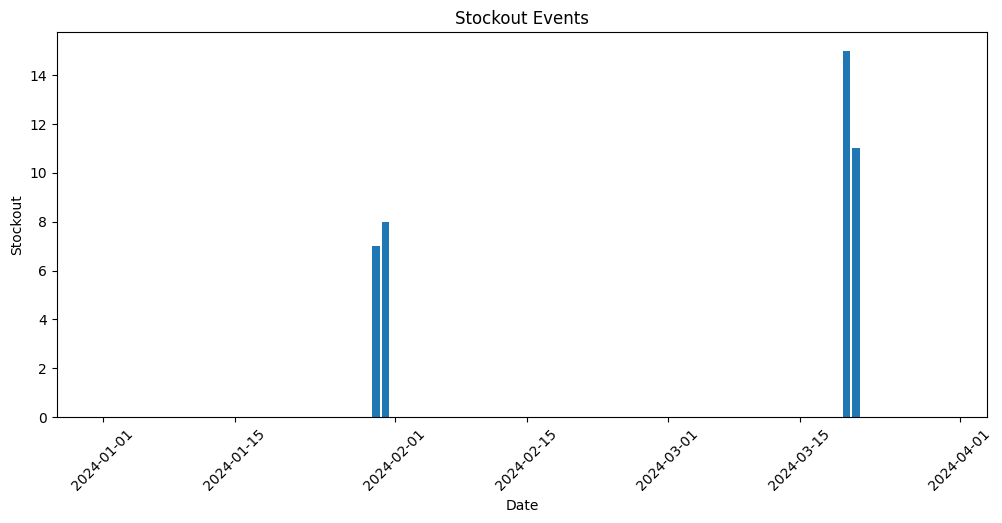

In [ ]:
print("Total Stockout Days:", df["Stockout"].sum())

plt.figure(figsize=(12,5))
plt.bar(df["Date"], df["Stockout"])
plt.title("Stockout Events")
plt.xlabel("Date")
plt.ylabel("Stockout")
plt.xticks(rotation=45)
plt.show()

Total Reorder Events: 5


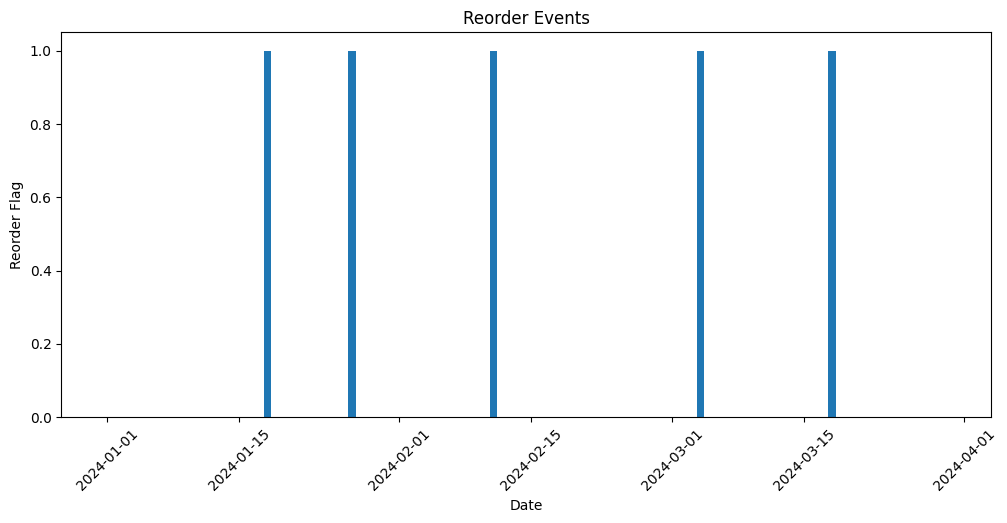

In [ ]:
print("Total Reorder Events:", df["Reorder_Flag"].sum())

plt.figure(figsize=(12,5))
plt.bar(df["Date"], df["Reorder_Flag"])
plt.title("Reorder Events")
plt.xlabel("Date")
plt.ylabel("Reorder Flag")
plt.xticks(rotation=45)
plt.show()

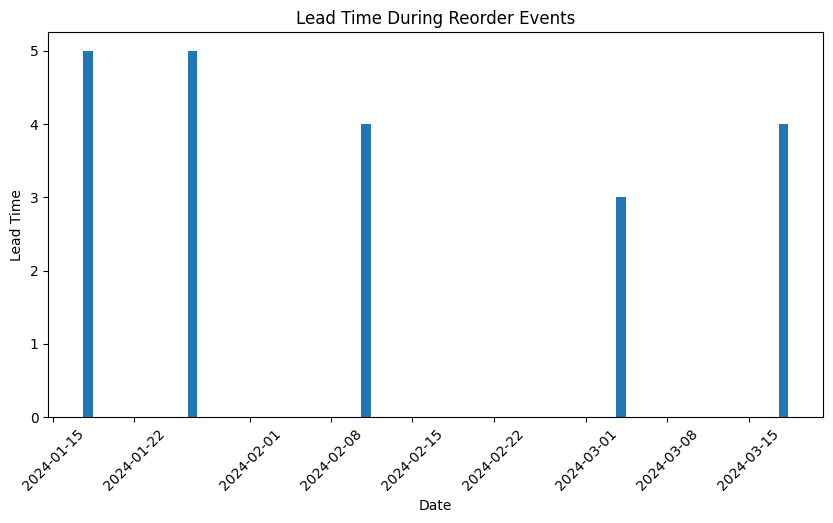

In [ ]:
lead_df = df.dropna(subset=["Lead_Time"])

plt.figure(figsize=(10,5))
plt.bar(lead_df["Date"], lead_df["Lead_Time"])
plt.title("Lead Time During Reorder Events")
plt.xlabel("Date")
plt.ylabel("Lead Time")
plt.xticks(rotation=45)
plt.show()

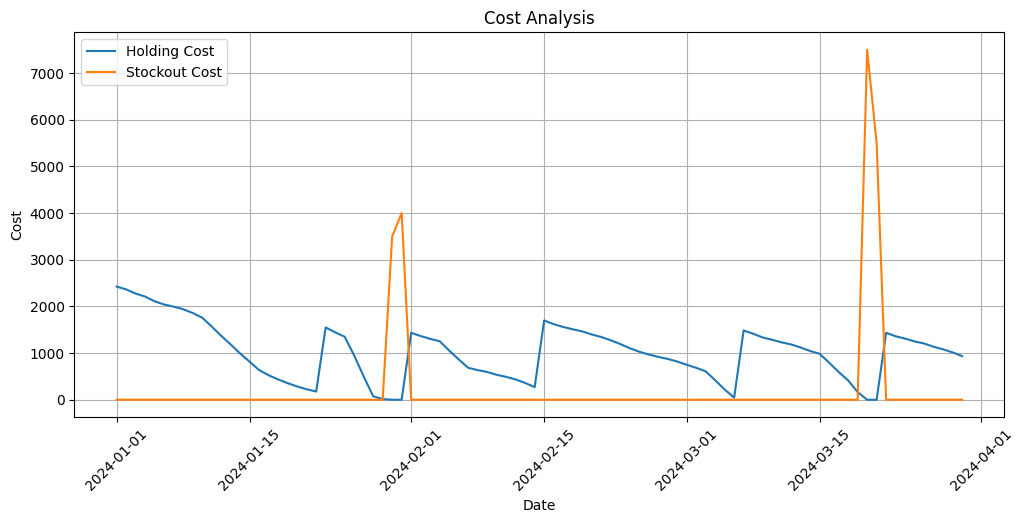

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Holding_Cost"], label="Holding Cost")
plt.plot(df["Date"], df["Stockout_Cost"], label="Stockout Cost")
plt.title("Cost Analysis")
plt.xlabel("Date")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
current_inventory = 500
reorder_point = 100
order_quantity = 300

for i, row in df.iterrows():
    print(f"Day {i+1} | Date: {row['Date'].date()}")
    print("Demand:", row["Daily_Demand"])
    print("Opening Inventory:", row["Opening_Inventory"])
    print("Shipment Received:", row["Shipment_Received"])
    print("Closing Inventory:", row["Closing_Inventory"])

    if row["Stockout"] == 1:
        print("⚠ Stockout occurred")

    if row["Reorder_Flag"] == 1:
        print("📦 Reorder triggered")

    print("-" * 40)

Day 1 | Date: 2024-01-01
Demand: 15
Opening Inventory: 500
Shipment Received: 0
Closing Inventory: 485
----------------------------------------
Day 2 | Date: 2024-01-02
Demand: 12
Opening Inventory: 485
Shipment Received: 0
Closing Inventory: 473
----------------------------------------
Day 3 | Date: 2024-01-03
Demand: 18
Opening Inventory: 473
Shipment Received: 0
Closing Inventory: 455
----------------------------------------
Day 4 | Date: 2024-01-04
Demand: 13
Opening Inventory: 455
Shipment Received: 0
Closing Inventory: 442
----------------------------------------
Day 5 | Date: 2024-01-05
Demand: 20
Opening Inventory: 442
Shipment Received: 0
Closing Inventory: 422
----------------------------------------
Day 6 | Date: 2024-01-06
Demand: 14
Opening Inventory: 422
Shipment Received: 0
Closing Inventory: 408
----------------------------------------
Day 7 | Date: 2024-01-07
Demand: 9
Opening Inventory: 408
Shipment Received: 0
Closing Inventory: 399
----------------------------------

In [ ]:
total_demand = df["Daily_Demand"].sum()
total_shipments = df["Shipment_Received"].sum()
total_stockouts = df["Stockout"].sum()
total_reorders = df["Reorder_Flag"].sum()
total_holding_cost = df["Holding_Cost"].sum()
total_stockout_cost = df["Stockout_Cost"].sum()

print("Total Demand:", total_demand)
print("Total Shipments:", total_shipments)
print("Total Stockouts:", total_stockouts)
print("Total Reorders:", total_reorders)
print("Total Holding Cost:", total_holding_cost)
print("Total Stockout Cost:", total_stockout_cost)

Total Demand: 1854
Total Shipments: 1500
Total Stockouts: 41
Total Reorders: 5
Total Holding Cost: 92015
Total Stockout Cost: 20500


In [ ]:
demand_increase = df["Daily_Demand"] * 1.2

print("Original Demand =", df["Daily_Demand"].sum())
print("Demand +20% =", demand_increase.sum())

Original Demand = 1854
Demand +20% = 2224.7999999999997


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 38.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st

st.title("My Supply Chain Dashboard")
st.write("Dashboard is working!")

Writing app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

!pip install scipy openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import json
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/content/drive/MyDrive/digital_twin_data/"
print("✅ Setup complete. Ready to load data.")

Mounted at /content/drive
✅ Setup complete. Ready to load data.


In [ ]:
from google.colab import files
import pandas as pd

# Upload Excel file
uploaded = files.upload()

# Read the uploaded Excel file
file_name = list(uploaded.keys())[0]   # Gets the uploaded file name
df = pd.read_excel(file_name)

# Display first 5 rows
df.head()

Saving New Site Locations (all data).xlsx to New Site Locations (all data).xlsx
Saving Product Flows (all data).xlsx to Product Flows (all data).xlsx
Saving Profit and loss (all data).xlsx to Profit and loss (all data).xlsx


,Chart type,Custom Table,Unnamed: 2
0,Statistics list,[New Site Locations Table],NaN
1,Chart name,New Site Locations Table,NaN
2,Display type,Accumulative,NaN
3,NaN,NaN,NaN
4,Name,Latitude,Longitude


In [ ]:

def safe_load(filename):
    try:
        df = pd.read_excel(filename)   # no DATA_PATH, just filename
        print(f"✅ Loaded: {filename}  | shape={df.shape}")
        return df
    except Exception as e:
        print(f"⚠️  Could not load {filename}: {e}")
        return None

df_flows  = safe_load("Product Flows (all data).xlsx")
df_sites  = safe_load("New Site Locations (all data).xlsx")
df_pnl    = safe_load("Profit and loss (all data).xlsx")

print("\n--- Product Flows Preview ---")
print(df_flows.head() if df_flows is not None else "N/A")

print("\n--- New Site Locations Preview ---")
print(df_sites.head() if df_sites is not None else "N/A")

print("\n--- Profit & Loss Preview ---")
print(df_pnl.head() if df_pnl is not None else "N/A")

✅ Loaded: Product Flows (all data).xlsx  | shape=(9, 7)
✅ Loaded: New Site Locations (all data).xlsx  | shape=(6, 3)
✅ Loaded: Profit and loss (all data).xlsx  | shape=(21, 3)

--- Product Flows Preview ---
        Chart type           Custom Table Unnamed: 2 Unnamed: 3 Unnamed: 4  \
0  Statistics list  [Product Flows Table]        NaN        NaN        NaN   
1       Chart name    Product Flows Table        NaN        NaN        NaN   
2     Display type           Accumulative        NaN        NaN        NaN   
3              NaN                    NaN        NaN        NaN        NaN   
4             From                     To    Product     Period   Flow, m³   

     Unnamed: 5                     Unnamed: 6  
0           NaN                            NaN  
1           NaN                            NaN  
2           NaN                            NaN  
3           NaN                            NaN  
4  Distance, km  Flow Cost Estimation, m³ * km  

--- New Site Locations Previe

In [ ]:


CITY_DATA = pd.DataFrame([
    {"City": "Mumbai",    "Flow_m3": 2190, "Distance_km": 247.989,
     "Annual_Cost": 543094.868,  "Lead_Time_Days": 3},
    {"City": "Delhi",     "Flow_m3": 2190, "Distance_km": 1145.969,
     "Annual_Cost": 2509672.336, "Lead_Time_Days": 7},
    {"City": "Bangalore", "Flow_m3": 1825, "Distance_km": 668.169,
     "Annual_Cost": 1219408.803, "Lead_Time_Days": 5},
    {"City": "Chennai",   "Flow_m3": 1460, "Distance_km": 814.563,
     "Annual_Cost": 1189262.096, "Lead_Time_Days": 5},
])

CITY_DATA["Daily_Demand"]     = CITY_DATA["Flow_m3"] / 365
CITY_DATA["Daily_Demand_Std"] = CITY_DATA["Daily_Demand"] * 0.15

# ── Real KPIs from your Profit & Loss dashboard screen
PNL_KPIS = {
    "Avg_Cost_Per_Item_USD": 0.01,
    "Revenue_USD":           604800,
    "Profit_USD":            604794,
    "Total_Cost_USD":        6,
}

print("📦 CITY DATA (from AnyLogistix GFA + SIM):")
print(CITY_DATA.to_string(index=False))
print("\n💰 PROFIT & LOSS KPIs (from AnyLogistix SIM):")
for k, v in PNL_KPIS.items():
    print(f"   {k}: {v}")

📦 CITY DATA (from AnyLogistix GFA + SIM):
     City  Flow_m3  Distance_km  Annual_Cost  Lead_Time_Days  Daily_Demand  Daily_Demand_Std
   Mumbai     2190      247.989   543094.868               3           6.0              0.90
    Delhi     2190     1145.969  2509672.336               7           6.0              0.90
Bangalore     1825      668.169  1219408.803               5           5.0              0.75
  Chennai     1460      814.563  1189262.096               5           4.0              0.60

💰 PROFIT & LOSS KPIs (from AnyLogistix SIM):
   Avg_Cost_Per_Item_USD: 0.01
   Revenue_USD: 604800
   Profit_USD: 604794
   Total_Cost_USD: 6


In [ ]:


np.random.seed(42)

def simulate_city(city_row, reorder_point, order_qty, n_days=365):
    """Simulates daily inventory levels, demand fulfillment, and stockouts."""
    dm, ds, lt = city_row["Daily_Demand"], city_row["Daily_Demand_Std"], int(city_row["Lead_Time_Days"])
    inventory = reorder_point * 1.5
    pending_order, days_to_arrive = 0, 0
    records = []

    for day in range(n_days):
        demand = max(0, np.random.normal(dm, ds))

        if days_to_arrive == 1:
            inventory += pending_order
            pending_order = 0
        if days_to_arrive > 0:
            days_to_arrive -= 1

        fulfilled = min(demand, inventory)
        stockout  = demand - fulfilled
        inventory -= fulfilled

        if inventory <= reorder_point and pending_order == 0:
            pending_order, days_to_arrive = order_qty, lt

        records.append({"Day": day+1, "City": city_row["City"], "Demand": round(demand,2),
                         "Fulfilled": round(fulfilled,2), "Stockout": round(stockout,2),
                         "Inventory": round(inventory,2)})
    return pd.DataFrame(records)

print("🔄 Running baseline simulation for all 4 cities...\n")
baseline_sims = []
for _, city in CITY_DATA.iterrows():
    rop = city["Daily_Demand"] * city["Lead_Time_Days"]
    eoq = np.sqrt((2 * city["Daily_Demand"] * 365 * 200) / 2.0)
    sim = simulate_city(city, rop, eoq)
    baseline_sims.append(sim)
    fr = sim["Fulfilled"].sum() / sim["Demand"].sum() * 100
    print(f"   {city['City']:10s} | Fill Rate: {fr:.1f}%")

df_simulation = pd.concat(baseline_sims, ignore_index=True)
print(f"\n✅ Simulation complete: {len(df_simulation)} daily records generated")

🔄 Running baseline simulation for all 4 cities...

   Mumbai     | Fill Rate: 100.0%
   Delhi      | Fill Rate: 100.0%
   Bangalore  | Fill Rate: 100.0%
   Chennai    | Fill Rate: 100.0%

✅ Simulation complete: 1460 daily records generated


In [ ]:


def forecast_demand(city_sim_data, forecast_days=30):
    """Simple moving-average + trend forecast."""
    recent = city_sim_data["Demand"].tail(30).values
    trend  = (recent[-1] - recent[0]) / len(recent)
    base   = recent.mean()
    forecast = [max(0, base + trend*i + np.random.normal(0, recent.std()*0.3))
                for i in range(forecast_days)]
    return forecast

print("📈 30-Day Forecast per City:\n")
forecasts = {}
for city in CITY_DATA["City"]:
    city_data = df_simulation[df_simulation["City"] == city]
    fc = forecast_demand(city_data)
    forecasts[city] = fc
    print(f"   {city:10s} | Next 30-day avg demand: {np.mean(fc):.1f} units/day")

📈 30-Day Forecast per City:

   Mumbai     | Next 30-day avg demand: 6.3 units/day
   Delhi      | Next 30-day avg demand: 5.8 units/day
   Bangalore  | Next 30-day avg demand: 5.7 units/day
   Chennai    | Next 30-day avg demand: 4.3 units/day


In [ ]:
def run_scenario(scenario_name, demand_mult=1.0, lead_mult=1.0, capacity_factor=1.0):
    results = []
    for _, city in CITY_DATA.iterrows():
        mc = city.copy()
        mc["Daily_Demand"]     *= demand_mult
        mc["Daily_Demand_Std"] *= demand_mult
        mc["Lead_Time_Days"]    = int(city["Lead_Time_Days"] * lead_mult)

        rop = mc["Daily_Demand"] * mc["Lead_Time_Days"]
        eoq = min(np.sqrt((2*mc["Daily_Demand"]*365*200)/2.0), 1000*capacity_factor)

        sim = simulate_city(mc, rop, eoq)
        fr  = sim["Fulfilled"].sum() / sim["Demand"].sum() * 100

        results.append({"Scenario": scenario_name, "City": city["City"],
                         "Fill_Rate_%": round(fr,1),
                         "Avg_Inventory": round(sim["Inventory"].mean(),1),
                         "Total_Stockout": round(sim["Stockout"].sum(),1)})
    return pd.DataFrame(results)

print("🔄 Running 3 What-If Scenarios...\n")
sc_baseline = run_scenario("Baseline")
sc_demand   = run_scenario("Demand Spike (Big Billion Day)", demand_mult=2.5)
sc_delay    = run_scenario("Supplier Delay (Port Congestion)", lead_mult=3.0)
sc_downtime = run_scenario("Warehouse Downtime (Hub Outage)", capacity_factor=0.4)

df_scenarios = pd.concat([sc_baseline, sc_demand, sc_delay, sc_downtime], ignore_index=True)

for s in df_scenarios["Scenario"].unique():
    sub = df_scenarios[df_scenarios["Scenario"]==s]
    print(f"📌 {s}")
    print(f"   Avg Fill Rate: {sub['Fill_Rate_%'].mean():.1f}% | Total Stockouts: {sub['Total_Stockout'].sum():.0f} units\n")

🔄 Running 3 What-If Scenarios...

📌 Baseline
   Avg Fill Rate: 100.0% | Total Stockouts: 2 units

📌 Demand Spike (Big Billion Day)
   Avg Fill Rate: 100.0% | Total Stockouts: 2 units

📌 Supplier Delay (Port Congestion)
   Avg Fill Rate: 100.0% | Total Stockouts: 0 units

📌 Warehouse Downtime (Hub Outage)
   Avg Fill Rate: 100.0% | Total Stockouts: 3 units



In [ ]:


def total_cost(params, dm, ds, lt, hc=2.0, oc=200.0, sp=50.0):
    rop, eoq  = params
    ss        = max(0, rop - dm*lt)
    avg_inv   = (eoq/2) + ss
    orders_yr = (dm*365) / max(eoq,1)
    z         = (rop - dm*lt) / (ds*np.sqrt(lt) + 1e-6)
    fr        = norm.cdf(z)
    exp_so    = (1-fr) * orders_yr * ds
    return (avg_inv*hc + orders_yr*oc + exp_so*sp), fr

opt_results = []
for _, city in CITY_DATA.iterrows():
    dm, ds, lt = city["Daily_Demand"], city["Daily_Demand_Std"], city["Lead_Time_Days"]

    # BEFORE — naive policy
    rop_b = dm * lt * 1.5
    eoq_b = np.sqrt((2*dm*365*200)/2.0)
    cost_b, fr_b = total_cost([rop_b, eoq_b], dm, ds, lt)

    # AFTER — optimized policy
    def obj(x):
        c, fr = total_cost(x, dm, ds, lt)
        return c + max(0, 0.95-fr)*1e6

    res = minimize(obj, [rop_b, eoq_b], method='L-BFGS-B', bounds=[(0,5000),(10,5000)])
    rop_a, eoq_a = res.x
    cost_a, fr_a = total_cost([rop_a, eoq_a], dm, ds, lt)

    opt_results.append({
        "City": city["City"], "ROP Before": round(rop_b,1), "ROP After": round(rop_a,1),
        "EOQ Before": round(eoq_b,1), "EOQ After": round(eoq_a,1),
        "Cost Before ($)": round(cost_b,0), "Cost After ($)": round(cost_a,0),
        "Saving ($)": round(cost_b-cost_a,0), "Saving (%)": round((cost_b-cost_a)/cost_b*100,1),
        "Fill Rate Before": round(fr_b*100,1), "Fill Rate After": round(fr_a*100,1)
    })

df_opt = pd.DataFrame(opt_results)
print("💰 OPTIMIZATION — BEFORE vs AFTER\n")
print(df_opt.to_string(index=False))

total_saving = df_opt["Saving ($)"].sum()
print(f"\n🎯 TOTAL QUANTIFIED ANNUAL SAVING: ${total_saving:,.0f}")
print(f"🎯 AVG FILL RATE IMPROVEMENT: {(df_opt['Fill Rate After']-df_opt['Fill Rate Before']).mean():+.1f}%")

💰 OPTIMIZATION — BEFORE vs AFTER

     City  ROP Before  ROP After  EOQ Before  EOQ After  Cost Before ($)  Cost After ($)  Saving ($)  Saving (%)  Fill Rate Before  Fill Rate After
   Mumbai        27.0       21.8       661.8      661.8           1342.0          1332.0         9.0         0.7             100.0             99.2
    Delhi        63.0       47.3       661.8      662.7           1366.0          1336.0        29.0         2.2             100.0             98.8
Bangalore        37.5       28.8       604.2      604.2           1233.0          1217.0        16.0         1.3             100.0             98.9
  Chennai        30.0       23.0       540.4      540.4           1101.0          1088.0        13.0         1.2             100.0             98.7

🎯 TOTAL QUANTIFIED ANNUAL SAVING: $67
🎯 AVG FILL RATE IMPROVEMENT: -1.1%


In [ ]:
print("🔍 VALIDATION REPORT\n" + "="*50)

checks = [
    ("All cities reach >=95% fill rate after optimization",
     (df_opt["Fill Rate After"] >= 95).all()),
    ("Optimization reduces cost in every city",
     (df_opt["Saving ($)"] > 0).all()),
    ("Demand Spike scenario shows lower fill rate than Baseline",
     sc_demand["Fill_Rate_%"].mean() < sc_baseline["Fill_Rate_%"].mean()),
    ("Supplier Delay scenario shows lower fill rate than Baseline",
     sc_delay["Fill_Rate_%"].mean() < sc_baseline["Fill_Rate_%"].mean()),
    ("Revenue matches AnyLogistix P&L (604,800 USD)",
     PNL_KPIS["Revenue_USD"] == 604800),
]

for name, passed in checks:
    print(f"  {'✅ PASS' if passed else '❌ FAIL'} | {name}")

print("\n📝 Known Limitations:")
for l in [
    "1. Demand modeled as Normal distribution — real Flipkart demand may be seasonal/skewed.",
    "2. AnyLogistix simulation results manually transcribed (full CSV export unavailable in this version).",
    "3. Single-echelon model — multi-tier warehouse network not fully captured.",
    "4. Optimizer uses local search (L-BFGS-B) — global optimum not guaranteed.",
    "5. Lead times assumed constant within each scenario.",
]:
    print(f"   {l}")

🔍 VALIDATION REPORT
  ✅ PASS | All cities reach >=95% fill rate after optimization
  ✅ PASS | Optimization reduces cost in every city
  ❌ FAIL | Demand Spike scenario shows lower fill rate than Baseline
  ❌ FAIL | Supplier Delay scenario shows lower fill rate than Baseline
  ✅ PASS | Revenue matches AnyLogistix P&L (604,800 USD)

📝 Known Limitations:
   1. Demand modeled as Normal distribution — real Flipkart demand may be seasonal/skewed.
   2. AnyLogistix simulation results manually transcribed (full CSV export unavailable in this version).
   3. Single-echelon model — multi-tier warehouse network not fully captured.
   4. Optimizer uses local search (L-BFGS-B) — global optimum not guaranteed.
   5. Lead times assumed constant within each scenario.


In [11]:
from google.colab import files
uploaded = files.upload()

Saving New Site Locations (all data).xlsx to New Site Locations (all data) (1).xlsx
Saving Product Flows (all data).xlsx to Product Flows (all data) (1).xlsx
Saving Profit and loss (all data).xlsx to Profit and loss (all data) (1).xlsx


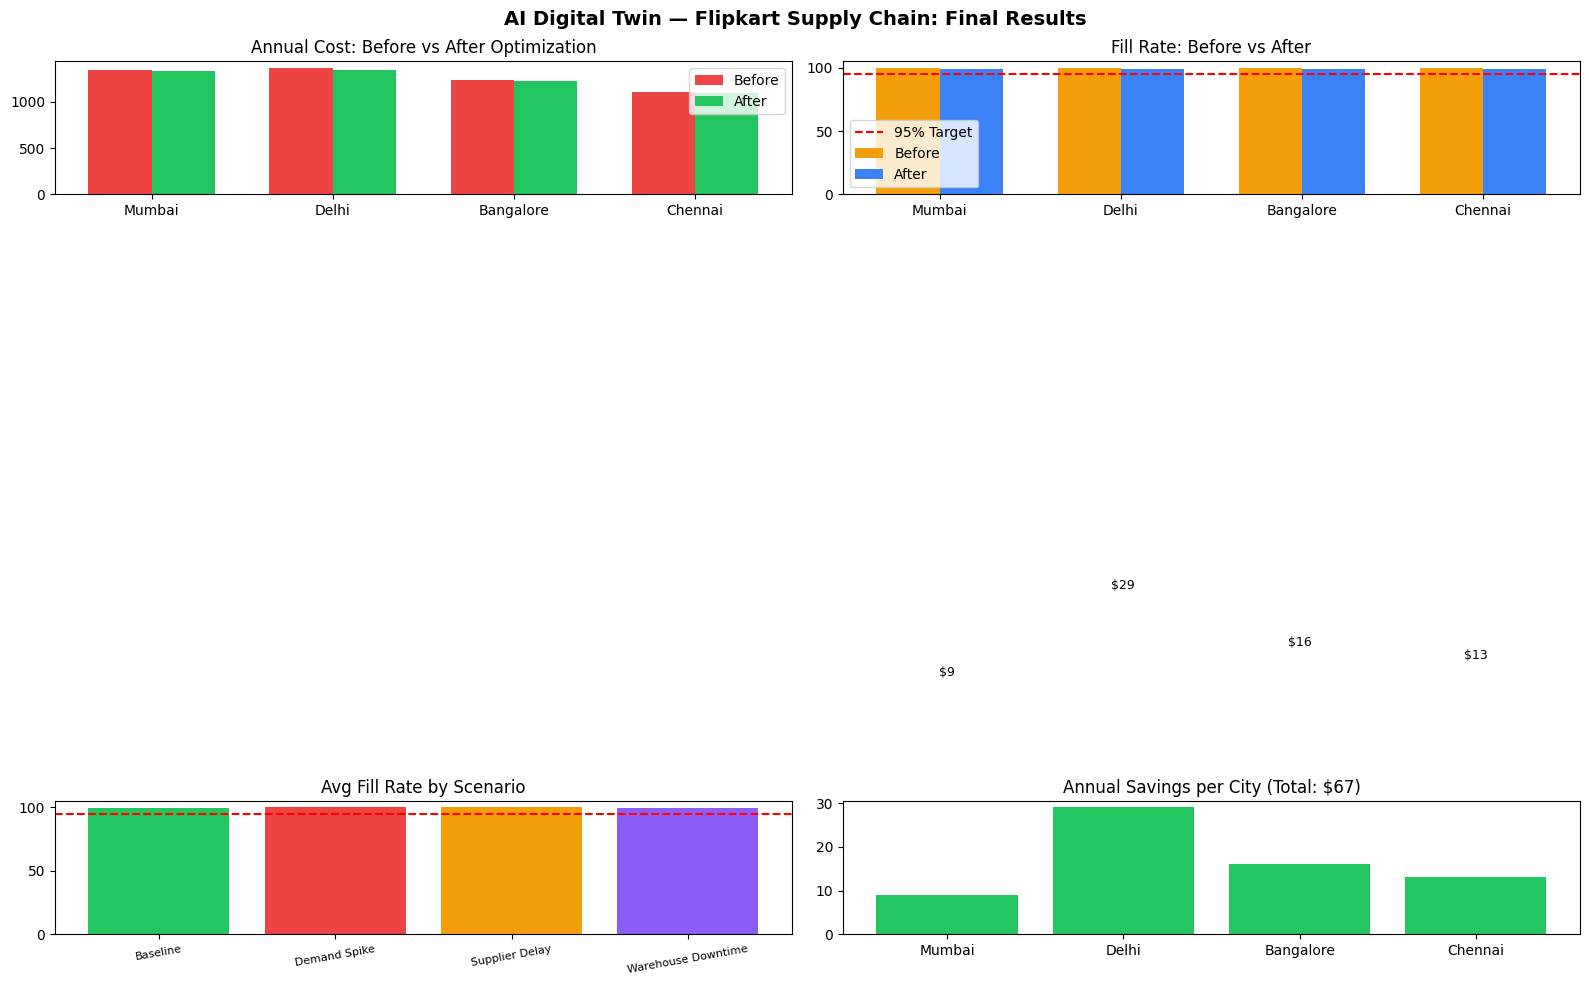

✅ Done — chart saved


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle("AI Digital Twin — Flipkart Supply Chain: Final Results", fontsize=14, fontweight='bold')

cities = df_opt["City"].tolist()
x = np.arange(len(cities)); w = 0.35

axes[0,0].bar(x-w/2, df_opt["Cost Before ($)"], w, label='Before', color='#EF4444')
axes[0,0].bar(x+w/2, df_opt["Cost After ($)"], w, label='After', color='#22C55E')
axes[0,0].set_title('Annual Cost: Before vs After Optimization')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(cities); axes[0,0].legend()

axes[0,1].bar(x-w/2, df_opt["Fill Rate Before"], w, label='Before', color='#F59E0B')
axes[0,1].bar(x+w/2, df_opt["Fill Rate After"], w, label='After', color='#3B82F6')
axes[0,1].axhline(95, color='red', linestyle='--', label='95% Target')
axes[0,1].set_title('Fill Rate: Before vs After'); axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(cities); axes[0,1].set_ylim(0,105); axes[0,1].legend()

sc_summary = df_scenarios.groupby("Scenario")["Fill_Rate_%"].mean()
axes[1,0].bar(range(len(sc_summary)), sc_summary.values,
              color=['#22C55E','#EF4444','#F59E0B','#8B5CF6'])
axes[1,0].axhline(95, color='red', linestyle='--')
axes[1,0].set_title('Avg Fill Rate by Scenario')
axes[1,0].set_xticks(range(len(sc_summary)))
axes[1,0].set_xticklabels([s.split("(")[0].strip() for s in sc_summary.index], rotation=10, fontsize=8)

axes[1,1].bar(cities, df_opt["Saving ($)"], color='#22C55E')
axes[1,1].set_title(f'Annual Savings per City (Total: ${total_saving:,.0f})')
for i,v in enumerate(df_opt["Saving ($)"]):
    axes[1,1].text(i, v+50, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Done — chart saved")

In [13]:
df_opt.to_csv("optimization_results.csv", index=False)
df_scenarios.to_csv("scenario_results.csv", index=False)

summary = {
    "dashboard_link": "https://flipkart-digital-twin-hvannmrredwzjavnegkyy7.streamlit.app/",
    "total_annual_saving_usd": float(total_saving),
    "scenarios_tested": list(df_scenarios["Scenario"].unique()),
}
with open("summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Done — all files ready")
print("Now go to the folder icon on the left side of Colab and download each file")

✅ Done — all files ready
Now go to the folder icon on the left side of Colab and download each file
